In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import style
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, roc_curve, accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

In [21]:
df = pd.read_excel("Data/datos_limpios.xlsx")
df

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Fiador,Impago,Prima,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial
0,JKLXIQ,51,56857,102886,718,338,3,6.18,24,0.55,...,0,0,580.00,1,0,0,0,1,0,0
1,4UO7DJ,46,45840,30473,689,291,1,14.28,36,0.34,...,0,0,431.25,1,0,0,0,1,0,0
2,MO3OJW,36,48156,188824,675,161,2,13.35,36,0.55,...,0,0,760.00,0,0,1,0,0,1,0
3,I14TTP,42,41472,40000,582,312,1,11.83,12,0.44,...,1,0,385.66,0,1,0,0,0,1,0
4,8FUIBH,60,70202,40743,652,489,2,9.27,48,0.25,...,1,0,535.14,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76505,SXTHNM,24,17942,40000,823,35,2,12.52,36,0.55,...,0,1,540.62,0,0,1,0,1,0,0
76506,0U329X,54,35399,14989,709,445,1,5.93,48,0.47,...,0,1,164.30,0,0,1,0,0,0,1
76507,MY63P5,28,17390,5000,744,92,3,16.12,12,0.10,...,0,0,26.80,0,0,1,0,1,0,0
76508,EPB8QX,64,40369,40000,680,447,2,7.75,12,0.19,...,1,1,207.42,1,0,0,0,0,1,0


In [22]:
print("Número de observaciones por clase")
print(df['Impago'].value_counts())
print("")

print("Porcentaje de observaciones por clase")
print(100 * df['Impago'].value_counts(normalize=True))


Número de observaciones por clase
Impago
0    67651
1     8859
Name: count, dtype: int64

Porcentaje de observaciones por clase
Impago
0    88.421121
1    11.578879
Name: proportion, dtype: float64


El 88% de los correos no son spam y el 11% sí lo son. Un modelo de clasificación que sea útil debe de ser capaz de predecir correctamente un porcentaje de observaciones por encima del porcentaje de la clase mayoritaria. En este caso, el umbral de referencia que se tiene que superar es del 88%.

['ID', 'Edad', 'Ingresos', 'Monto_Inicial', 'Scoring_Crediticio',
       'Meses_Empleo', 'Num_Creditos', 'Ratio_Interes', 'Duracion',
       'Ratio_Deuda_Ingresos', 'Estudios', 'Posesion_Hipoteca',
       'Personas_Cargo', 'Fiador', 'Impago', 'Prima', 'Estado_Civil_Casado',
       'Estado_Civil_Divorciado', 'Estado_Civil_Soltero',
       'Tipo_Jornada_Laboral_Autónomo', 'Tipo_Jornada_Laboral_Desempleado',
       'Tipo_Jornada_Laboral_Jornada completa',
       'Tipo_Jornada_Laboral_Tiempo parcial']

In [23]:

X = df[['Edad','Monto_Inicial', 'Scoring_Crediticio','Ratio_Deuda_Ingresos','Ratio_Interes']] 
y = df['Impago']

X_train, X_test, y_train, y_test = train_test_split(
                                        X, y,
                                        train_size   = 0.8,
                                        random_state = 42,
                                        shuffle      = True,
                                        stratify = y)

In [24]:
# Escalado de variables

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

In [25]:
# 2. Undersampling: Reducimos los buenos pagadores (clase 0)
undersampler = RandomUnderSampler(sampling_strategy={0: 30000}, random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train_scaled, y_train)

# 3. SMOTE: Subimos los morosos (clase 1)
smote = SMOTE(sampling_strategy={1: 30000}, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_under, y_train_under)

print(f"Distribución para entrenar -> 0: {sum(y_train_resampled==0)} | 1: {sum(y_train_resampled==1)}")

Distribución para entrenar -> 0: 30000 | 1: 30000


In [26]:
modelo_log_sklearn = LogisticRegression(random_state=42, max_iter=1000)
modelo_log_sklearn.fit(X_train_resampled, y_train_resampled)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [27]:
# Información del modelo
print("Intercept:", modelo_log_sklearn.intercept_)
print("Coeficiente:", list(zip(X_train_resampled.columns, modelo_log_sklearn.coef_.flatten(), )))
print("Accuracy de entrenamiento:", modelo_log_sklearn.score(X_train_resampled, y_train_resampled))

Intercept: [-0.17424469]
Coeficiente: [('Edad', np.float64(-0.5047266669283131)), ('Monto_Inicial', np.float64(-0.07679274771227555)), ('Scoring_Crediticio', np.float64(-0.09136916375602941)), ('Ratio_Deuda_Ingresos', np.float64(-0.01626828068999069)), ('Ratio_Interes', np.float64(0.4465566512866208))]
Accuracy de entrenamiento: 0.6325


In [28]:
# predict_proba()
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

predicciones = modelo_log_sklearn.predict_proba(X = X_test_scaled)
predicciones = pd.DataFrame(predicciones, columns = modelo_log_sklearn.classes_)
predicciones.head(5)

,0,1
0,0.407105,0.592895
1,0.411615,0.588385
2,0.424161,0.575839
3,0.580480,0.419520
4,0.639633,0.360367


In [29]:
# Creación del modelo utilizando matrices como sklearn

X_train_scaled = sm.add_constant(X_train_scaled, prepend=True)
modelo_log_statsm = sm.Logit(endog= y_train, exog = X_train_scaled)
modelo_log_statsm = modelo_log_statsm.fit()
print(modelo_log_statsm.summary())

Optimization terminated successfully.
         Current function value: 0.336653
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Impago   No. Observations:                61208
Model:                          Logit   Df Residuals:                    61202
Method:                           MLE   Df Model:                            5
Date:               ju., 08 oct. 2026   Pseudo R-squ.:                 0.06079
Time:                        16:06:02   Log-Likelihood:                -20606.
converged:                       True   LL-Null:                       -21940.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.2038      0.015   -151.641      0.000      -2.232      -2.175

In [30]:
intervalos_ci = modelo_log_statsm.conf_int(alpha=0.05).rename(columns={0: "2.5%", 1: "97.5%"})

intervalos_ci[:4]

,2.5%,97.5%
const,-2.232304,-2.175335
Edad,-0.544205,-0.488164
Monto_Inicial,-0.082014,-0.009843
Scoring_Crediticio,-0.116334,-0.065594


In [31]:
# Debemos añadir una columna de constante al conjunto de test 

X_test_scaled = sm.add_constant(X_test_scaled, has_constant='add')

predicciones = modelo_log_statsm.predict(exog = X_test_scaled)
predicciones[:4]

35450    0.162680
32706    0.160806
53994    0.145381
50667    0.088610
dtype: float64

In [ ]:
# 1. Calculamos las probabilidades 
probabilidades_train = modelo_log_statsm.predict(exog=X_train_scaled)

# 2. Obtenemos las metricas ROC 
fpr, tpr, thresholds = roc_curve(y_train, probabilidades_train)
umbral_optimo = thresholds[np.argmax(tpr - fpr)]

print(f"Umbral matematico perfecto: {umbral_optimo:.4f}")

# 3. Aplicamos el umbral a la variable predicciones 
clasificacion = np.where(predicciones < umbral_optimo, 0, 1)

print(clasificacion[:4])

Umbral matematico perfecto: 0.1143
[1 1 1 0]


### Métricas de rendimiento del modelo

- Accuracy

- precision

- sensibilidad (recall)

- f1-score

- Matriz de confusión

- Curva precisión/sensibilidad

- curva ROC-AUC

In [33]:
# Accuracy / Aciertos: 
""" 
Mide la proporción de predicciones correctas sobre el total de observaciones evaluadas
"""

from sklearn.metrics import accuracy_score

acierto = accuracy_score(y_test, clasificacion)
error = 1 - acierto
print("Acierto:", round(acierto*100, 2), "%")
print("Error:", round(error*100, 2), "%")

Acierto: 62.54 %
Error: 37.46 %


Acierto: 63.4 %
Error: 36.6 %

In [34]:
# Precisión, Recall, f1-score
""" 
Precision: Cada vez que el modelo predijo una clase, acerto ese porcentaje
Recall: De todos los datos que eran de esa clase, detectó ese porcentaje
F1-score: El valor será alto si precisión y sensibilidad son similares, útil para comparar clasificadores.
"""



from sklearn.metrics import classification_report

print(classification_report(y_test, clasificacion))


              precision    recall  f1-score   support

           0       0.94      0.62      0.74     13530
           1       0.19      0.68      0.30      1772

    accuracy                           0.63     15302
   macro avg       0.56      0.65      0.52     15302
weighted avg       0.85      0.63      0.69     15302



 0       0.94      0.63      0.75     13530
1        0.19      0.67      0.30      1772

[[8369 5161]
 [ 571 1201]]


<Axes: >

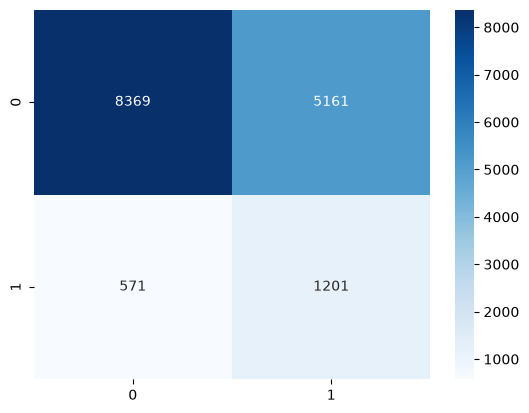

In [35]:
# Matriz de confusión

from sklearn.metrics import confusion_matrix

c_matrix = confusion_matrix(y_test, clasificacion)
print(c_matrix)

sns.heatmap(c_matrix,annot=True, fmt="d", cmap="Blues")

In [36]:
## Curva precisión/recall

""" 
Cómo varía la precisión y sensibilidad respecto a diferentes umbrales de probabilidad
"""
from sklearn.metrics import precision_recall_curve

# Primero creamos una tabla para ver como varía la precisión y recall en función del valor umbral

prec, rec, thresholds = precision_recall_curve(y_test, predicciones) # necesitamos la probabilidad de la clase 1
pd.DataFrame({"prec":prec[:-1], "rec":rec[:-1], "threshold":thresholds})[80:100]


,prec,rec,threshold
80,0.116279,0.998871,0.020009
81,0.116287,0.998871,0.020030
82,0.116294,0.998871,0.020060
83,0.116302,0.998871,0.020072
84,0.116310,0.998871,0.020089
85,0.116317,0.998871,0.020133
86,0.116325,0.998871,0.020181
87,0.116333,0.998871,0.020215
88,0.116340,0.998871,0.020340
89,0.116348,0.998871,0.020368


Text(0.5, 1.0, 'PR Curve')

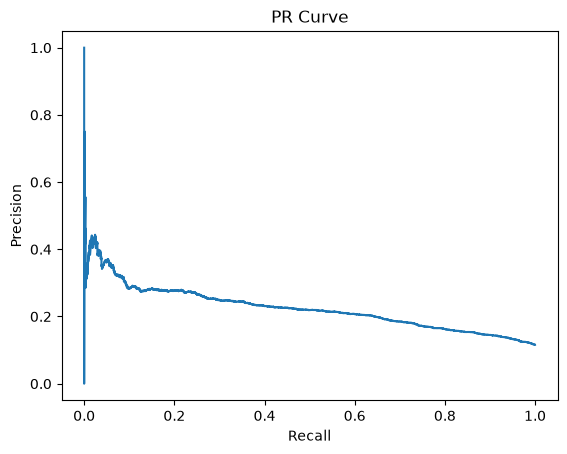

In [37]:
# Creamos la curva

plt.plot(rec, prec)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("PR Curve")

Text(0.5, 1.0, 'Curva ROC')

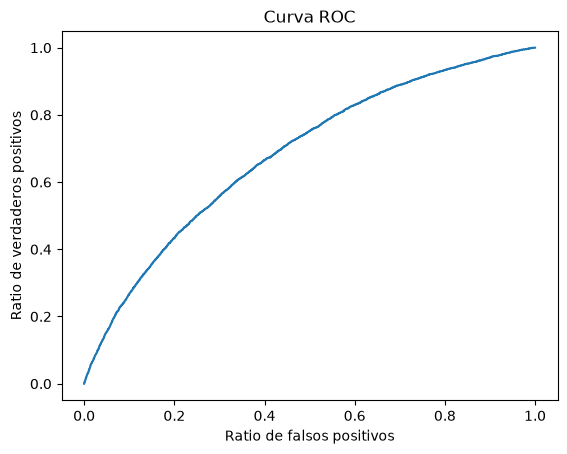

In [38]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)

plt.xlabel("Ratio de falsos positivos")
plt.ylabel("Ratio de verdaderos positivos")
plt.title("Curva ROC")